In [ ]:
# Tissue Spatial Geometrics Lab | David H. Nguyen, PhD

### Description ###
# This script turns matrices from the Distance & Connectivity Index (DCI) into
#   vectors that are columns of a dataframe. 
# This script was written to work with CSV files outputed by the software 
#   GlycoAssessor v0.3.0. The CSV files should be formatted exactly as 
#   shown in the image below. Column headers must be spelled exactly as shown.

### Insructions ###
# Paste the file path to the working directory that contains the csv files.
#   Paste this in the section called: 
#   "USER INPUT: Paste the file path to the directory"
# The output is a csv filed called "adjusted_vectorized.csv"


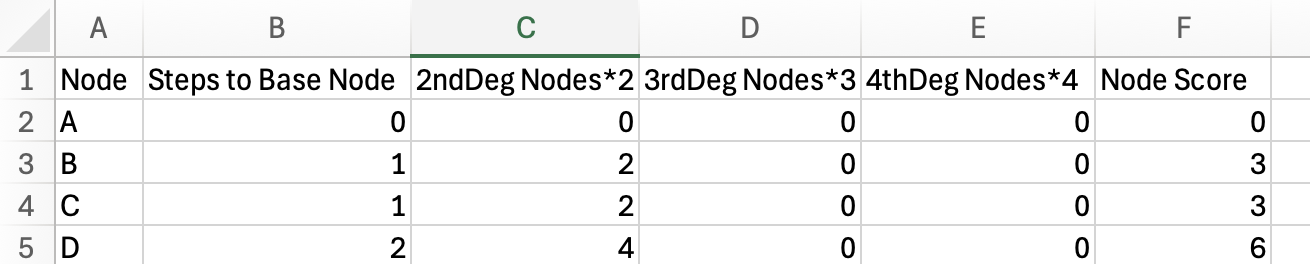

In [4]:
# Load the dependencies
import os
import glob
import warnings
import string

import numpy as np
import pandas as pd

In [6]:
# ============================================================
# USER INPUT: Paste the file path to the directory
# ============================================================

working_dir = 'filePathHere'

# Change working directory
os.chdir(working_dir)

print(f"Current working directory set to:\n{os.getcwd()}")


# ============================================================
# 0. Load all CSV files in working directory as dataframes
# ============================================================

csv_files = glob.glob("*.csv")

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files found in the specified directory."
    )

dataframes = {}  # name : dataframe

for file in csv_files:

    df_name = os.path.splitext(
        os.path.basename(file)
    )[0]

    dataframes[df_name] = pd.read_csv(file)

print(f"Loaded {len(dataframes)} CSV files.")


# ============================================================
# 1. Collect unique "Steps to Base Node" integers globally
# ============================================================

Global_Num_of_Steps = set()

for name, df in dataframes.items():

    unique_steps = df["Steps to Base Node"].unique()

    Global_Num_of_Steps.update(unique_steps)

Global_Num_of_Steps = sorted(list(Global_Num_of_Steps))

print("Global_Num_of_Steps:", Global_Num_of_Steps)


# ============================================================
# 2. Sort each dataframe by "Steps to Base Node"
# ============================================================

for name in dataframes:

    dataframes[name] = dataframes[name].sort_values(
        by="Steps to Base Node",
        ascending=True
    ).reset_index(drop=True)


# ============================================================
# 3. Create subsets per "Steps to Base Node" category
#    + assign unique row labels
# ============================================================

subsets = {}  # subset_name : dataframe

for df_name, df in dataframes.items():

    for step in df["Steps to Base Node"].unique():

        subset_name = f"{df_name}_Steps2BN_{step}"

        subset_df = df[
            df["Steps to Base Node"] == step
        ].copy()

        # --------------------------------------------
        # Assign row labels:
        # 1_A, 1_B, 1_C ...
        # --------------------------------------------

        row_labels = []

        for i in range(len(subset_df)):

            if i < 26:
                suffix = string.ascii_uppercase[i]
            else:
                suffix = f"A{i - 25}"

            row_labels.append(f"{step}_{suffix}")

        subset_df.index = row_labels

        subsets[subset_name] = subset_df


# ============================================================
# 4. Sort each subset by "2ndDeg Nodes*2"
# ============================================================

for subset_name in subsets:

    subsets[subset_name] = subsets[subset_name].sort_values(
        by="2ndDeg Nodes*2",
        ascending=True
    )


# ============================================================
# 5. Create Subsets_and_rowCounts dictionary
# ============================================================

Subsets_and_rowCounts = {}

for subset_name, subset_df in subsets.items():

    Subsets_and_rowCounts[subset_name] = len(subset_df)

print("Subsets_and_rowCounts created.")


# ============================================================
# 6. Ensure all dataframes have every category
#    and zero-pad subsets
# ============================================================

# ------------------------------------------------------------
# Guarantee every dataframe has every subset category
# ------------------------------------------------------------

for df_name in dataframes.keys():

    for step in Global_Num_of_Steps:

        subset_name = f"{df_name}_Steps2BN_{step}"

        if subset_name not in subsets:

            empty_df = pd.DataFrame(
                columns=dataframes[df_name].columns
            )

            subsets[subset_name] = empty_df


# ------------------------------------------------------------
# Rebuild category groups
# ------------------------------------------------------------

category_groups = {}

for subset_name in subsets:

    step = subset_name.split("_Steps2BN_")[1]

    category_groups.setdefault(step, []).append(subset_name)


# ------------------------------------------------------------
# Zero-pad subsets
# ------------------------------------------------------------

for step, subset_names in category_groups.items():

    max_rows = max(
        len(subsets[name])
        for name in subset_names
    )

    for name in subset_names:

        current_rows = len(subsets[name])

        if current_rows < max_rows:

            rows_to_add = max_rows - current_rows

            # ----------------------------------------
            # Generate padding row labels
            # ----------------------------------------

            padding_labels = []

            for i in range(rows_to_add):

                idx = current_rows + i

                if idx < 26:
                    suffix = string.ascii_uppercase[idx]
                else:
                    suffix = f"A{idx - 25}"

                padding_labels.append(f"{step}_{suffix}")

            # ----------------------------------------
            # Create zero block
            # ----------------------------------------

            zero_block = pd.DataFrame(
                0,
                index=padding_labels,
                columns=dataframes[
                    name.split("_Steps2BN_")[0]
                ].columns
            )

            subsets[name] = pd.concat(
                [subsets[name], zero_block],
                axis=0
            )

print("Zero-padding complete (including empty subsets).")


# ============================================================
# 7. Recombine subsets into augmented dataframes
# ============================================================

recombined_dataframes = {}

for df_name in dataframes.keys():

    matching_subsets = []

    for step in Global_Num_of_Steps:

        subset_name = f"{df_name}_Steps2BN_{step}"

        matching_subsets.append(subsets[subset_name])

    column_order = [
        "Steps to Base Node",
        "2ndDeg Nodes*2",
        "3rdDeg Nodes*3",
        "4thDeg Nodes*4",
        "Node Score"
    ]

    # Preserve row labels
    recombined_df = pd.concat(
        matching_subsets,
        ignore_index=False
    )

    recombined_df = recombined_df[column_order]

    recombined_dataframes[df_name] = recombined_df

print("Recombined dataframes created.")


# ============================================================
# 8. Vectorize each recombined dataframe
#    + preserve row labels
# ============================================================

vectors = {}

master_row_labels = None

for df_name, df in recombined_dataframes.items():

    stacked_vector = np.concatenate([

        df["Steps to Base Node"].values,

        df["2ndDeg Nodes*2"].values,

        df["3rdDeg Nodes*3"].values,

        df["4thDeg Nodes*4"].values,

        df["Node Score"].values

    ])

    vectors[df_name] = stacked_vector

    # --------------------------------------------------------
    # Create master row labels only once
    # --------------------------------------------------------

    if master_row_labels is None:

        labels = list(df.index)

        master_row_labels = (

            [f"{x}_Steps2BN" for x in labels] +

            [f"{x}_2ndDeg" for x in labels] +

            [f"{x}_3rdDeg" for x in labels] +

            [f"{x}_4thDeg" for x in labels] +

            [f"{x}_NodeScore" for x in labels]

        )

print("Vectorization complete.")


# ============================================================
# 9. Pad vectors to equal length and combine
# ============================================================

# Find maximum vector length
max_length = max(
    len(v)
    for v in vectors.values()
)

# ------------------------------------------------------------
# Pad vectors if necessary
# ------------------------------------------------------------

for name in vectors:

    current_length = len(vectors[name])

    if current_length < max_length:

        padding = np.zeros(
            max_length - current_length
        )

        vectors[name] = np.concatenate([
            vectors[name],
            padding
        ])

# ------------------------------------------------------------
# Pad row labels if necessary
# ------------------------------------------------------------

if len(master_row_labels) < max_length:

    extra = max_length - len(master_row_labels)

    master_row_labels.extend([
        f"Padding_{i}"
        for i in range(extra)
    ])

# ------------------------------------------------------------
# Create combined dataframe
# ------------------------------------------------------------

vectorized_combined = pd.DataFrame(vectors)

# Assign row labels
vectorized_combined.index = master_row_labels

print("Master dataframe 'vectorized_combined' created.")


# ============================================================
# 10. Check equal row length
# ============================================================

lengths = vectorized_combined.apply(len)

if len(set(lengths)) != 1:

    warnings.warn(
        "WARNING: Columns in 'vectorized_combined' "
        "do NOT have equal lengths."
    )

else:

    print(
        "All columns in 'vectorized_combined' "
        "have equal length."
    )

    print(f"Final vector length: {max_length}")


# ============================================================
# 11. Save as CSV
# ============================================================

output_path = os.path.join(
    working_dir,
    "adjusted_vectorized.csv"
)

# Save WITH row names
vectorized_combined.to_csv(
    output_path,
    index=True
)

print(
    f"'adjusted_vectorized.csv' saved to:\n"
    f"{output_path}"
)

Current working directory set to:
/Users/davidnguyen/Documents/Dave Personal Stuff/TSG Lab/Glycan Code/Prostate Cancer Glycans/Conroy Glycans_DCI_Vectorized_PCA/Vectorized using v2 of script_HAS row names/input
Loaded 31 CSV files.
Global_Num_of_Steps: [0, 1, 2, 3, 4, 5, 6]
Subsets_and_rowCounts created.
Zero-padding complete (including empty subsets).
Recombined dataframes created.
Vectorization complete.
Master dataframe 'vectorized_combined' created.
All columns in 'vectorized_combined' have equal length.
Final vector length: 80
'adjusted_vectorized.csv' saved to:
/Users/davidnguyen/Documents/Dave Personal Stuff/TSG Lab/Glycan Code/Prostate Cancer Glycans/Conroy Glycans_DCI_Vectorized_PCA/Vectorized using v2 of script_HAS row names/input/adjusted_vectorized.csv
